In [1]:
# python native
import os
import json
import random
import datetime
from functools import partial


In [2]:

# external library
import cv2
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from sklearn.model_selection import GroupKFold
import albumentations as A

# torch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models

# visualization
import matplotlib.pyplot as plt

/data/ephemeral/home/py310/lib/python3.10/site-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [3]:
TEST_IMAGE_ROOT = "../../test/DCM"
IMAGE_ROOT = "../../train/DCM"
LABEL_ROOT = "../../train/outputs_json"

In [4]:
CLASSES = [
    'finger-1', 'finger-2', 'finger-3', 'finger-4', 'finger-5',
    'finger-6', 'finger-7', 'finger-8', 'finger-9', 'finger-10',
    'finger-11', 'finger-12', 'finger-13', 'finger-14', 'finger-15',
    'finger-16', 'finger-17', 'finger-18', 'finger-19', 'Trapezium',
    'Trapezoid', 'Capitate', 'Hamate', 'Scaphoid', 'Lunate',
    'Triquetrum', 'Pisiform', 'Radius', 'Ulna',
]

In [5]:
pngs = {
    os.path.relpath(os.path.join(root, fname), start=IMAGE_ROOT)
    for root, _dirs, files in os.walk(IMAGE_ROOT)
    for fname in files
    if os.path.splitext(fname)[1].lower() == ".png"
}

In [6]:
jsons = {
    os.path.relpath(os.path.join(root, fname), start=LABEL_ROOT)
    for root, _dirs, files in os.walk(LABEL_ROOT)
    for fname in files
    if os.path.splitext(fname)[1].lower() == ".json"
}

In [7]:
jsons_fn_prefix = {os.path.splitext(fname)[0] for fname in jsons}
pngs_fn_prefix = {os.path.splitext(fname)[0] for fname in pngs}

assert len(jsons_fn_prefix - pngs_fn_prefix) == 0
assert len(pngs_fn_prefix - jsons_fn_prefix) == 0

In [8]:
pngs = sorted(pngs)
jsons = sorted(jsons)

In [9]:
CLASS2IND = {v: i for i, v in enumerate(CLASSES)}

In [10]:
IND2CLASS = {v: k for k, v in CLASS2IND.items()}

In [11]:
class XRayDataset(Dataset):
    def __init__(self, is_train=True, transforms=None):
        _filenames = np.array(pngs)
        _labelnames = np.array(jsons)
        
        # split train-valid
        # 한 폴더 안에 한 인물의 양손에 대한 `.dcm` 파일이 존재하기 때문에
        # 폴더 이름을 그룹으로 해서 GroupKFold를 수행합니다.
        # 동일 인물의 손이 train, valid에 따로 들어가는 것을 방지합니다.
        groups = [os.path.dirname(fname) for fname in _filenames]
        
        # dummy label
        ys = [0 for fname in _filenames]
        
        # 전체 데이터의 20%를 validation data로 쓰기 위해 `n_splits`를
        # 5으로 설정하여 KFold를 수행합니다.
        gkf = GroupKFold(n_splits=5)
        
        filenames = []
        labelnames = []
        for i, (x, y) in enumerate(gkf.split(_filenames, ys, groups)):
            if is_train:
                # 0번을 validation dataset으로 사용합니다.
                if i == 0:
                    continue
                    
                filenames += list(_filenames[y])
                labelnames += list(_labelnames[y])
            
            else:
                filenames = list(_filenames[y])
                labelnames = list(_labelnames[y])
                
                # skip i > 0
                break
        
        self.filenames = filenames
        self.labelnames = labelnames
        self.is_train = is_train
        self.transforms = transforms
        self.name2idx = {
    os.path.basename(fname): i
    for i, fname in enumerate(self.filenames)
}
    
    def __len__(self):
        return len(self.filenames)
    
    def __getitem__(self, item):
        image_name = self.filenames[item]
        image_path = os.path.join(IMAGE_ROOT, image_name)
        
        image = cv2.imread(image_path)
        image = image / 255.
        
        label_name = self.labelnames[item]
        label_path = os.path.join(LABEL_ROOT, label_name)
        
        # (H, W, NC) 모양의 label을 생성합니다.
        label_shape = tuple(image.shape[:2]) + (len(CLASSES), )
        label = np.zeros(label_shape, dtype=np.uint8)
        
        # label 파일을 읽습니다.
        with open(label_path, "r") as f:
            annotations = json.load(f)
        annotations = annotations["annotations"]
        
        # 클래스 별로 처리합니다.
        for ann in annotations:
            c = ann["label"]
            class_ind = CLASS2IND[c]
            points = np.array(ann["points"])
            
            
            # polygon 포맷을 dense한 mask 포맷으로 바꿉니다.
            class_label = np.zeros(image.shape[:2], dtype=np.int32) # 점 개수 ,x,y
            cv2.fillPoly(class_label, [points], 1) #여기서 형태가 안맞는다고? (n,1,2)를 기대하는데
            #n,2를 줘도 그냥 넘어간다는데
            label[..., class_ind] = class_label
        
        if self.transforms is not None:
            inputs = {"image": image, "mask": label} if self.is_train else {"image": image}
            result = self.transforms(**inputs)
            
            image = result["image"]
            label = result["mask"] if self.is_train else label

        # to tenser will be done later
        image = image.transpose(2, 0, 1)    # channel first 포맷으로 변경합니다.
        label = label.transpose(2, 0, 1)
        
        image = torch.from_numpy(image).float()
        label = torch.from_numpy(label).float()
            
        return image, label

In [12]:
tf = A.Resize(512, 512)

In [13]:
train_dataset = XRayDataset(is_train=True, transforms=tf)
valid_dataset = XRayDataset(is_train=False, transforms=tf)

In [14]:
model = torch.load(os.path.join("../src/datasets/", "deeplabv3_resnet50_best_model.pt"))

In [15]:
# 시각화를 위한 팔레트를 설정합니다.
PALETTE = [
    (220, 20, 60), (119, 11, 32), (0, 0, 142), (0, 0, 230), (106, 0, 228),
    (0, 60, 100), (0, 80, 100), (0, 0, 70), (0, 0, 192), (250, 170, 30),
    (100, 170, 30), (220, 220, 0), (175, 116, 175), (250, 0, 30), (165, 42, 42),
    (255, 77, 255), (0, 226, 252), (182, 182, 255), (0, 82, 0), (120, 166, 157),
    (110, 76, 0), (174, 57, 255), (199, 100, 0), (72, 0, 118), (255, 179, 240),
    (0, 125, 92), (209, 0, 151), (188, 208, 182), (0, 220, 176),
]

# 시각화 함수입니다. 클래스가 2개 이상인 픽셀을 고려하지는 않습니다.
def label2rgb(label):
    image_size = label.shape[1:] + (3, )
    image = np.zeros(image_size, dtype=np.uint8)
    
    for i, class_label in enumerate(label):
        image[class_label == 1] = PALETTE[i]
        
    return image

In [16]:
def visualization_val(model, img,gt, thr=0.5):
    model = model.cuda()
    model.eval()
    img = img.unsqueeze(0).cuda() 
    with torch.no_grad():
        n_class = len(CLASSES)
        outputs = model(img)['out']
            
        outputs = F.interpolate(outputs, size=(2048, 2048), mode="bilinear")
        outputs = torch.sigmoid(outputs)
        outputs = (outputs > thr).detach().cpu().numpy()
        
    
    pred_rgb = label2rgb(outputs.squeeze(0)) #처음에 batch_size 있으니까
    gt_rgb = label2rgb(gt.numpy())


    # 시각화
    plt.figure(figsize=(18, 4))

    plt.subplot(1, 3, 1)
    plt.title("Image")
    plt.imshow(img.squeeze(0).permute(1, 2, 0).cpu().numpy())
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("GT")
    plt.imshow(gt_rgb)
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title("Prediction")
    plt.imshow(pred_rgb) 
    plt.axis("off")

    plt.show()

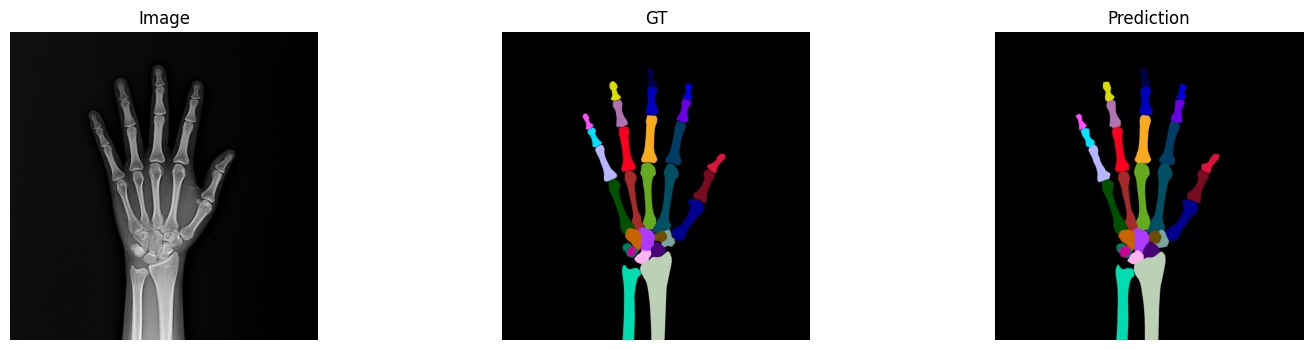

In [17]:
#원하는 파일명으로 접근
 
idx = valid_dataset.name2idx["image1661130891365_L.png"]
image, gt = valid_dataset[idx]
#dataset을 하니까 편하게 들어가지네
visualization_val(model, image,gt, thr=0.5)

In [18]:
def visualization_val_batch(model, dataset, indices=range(1,11), thr=0.5):
    model.eval()
    n_images = len(indices)
    
    plt.figure(figsize=(18, n_images * 4))  # 각 이미지마다 4 height 확보
    
    for i, idx in enumerate(indices):
        img, gt = dataset[idx]
        img_input = img.unsqueeze(0).cuda()
        
        with torch.no_grad():
            outputs = model(img_input)['out']
            outputs = F.interpolate(outputs, size=(2048, 2048), mode="bilinear")
            outputs = torch.sigmoid(outputs)
            outputs = (outputs > thr).detach().cpu().numpy()
        
        # RGB로 변환
        pred_rgb = label2rgb(outputs.squeeze(0))
        gt_rgb = label2rgb(gt.numpy())
        
        # 이미지 subplot
        plt.subplot(n_images, 3, i*3 + 1)
        plt.title(f"Image {idx}")
        plt.imshow(img.permute(1, 2, 0).numpy())
        plt.axis("off")
        
        plt.subplot(n_images, 3, i*3 + 2)
        plt.title("GT")
        plt.imshow(gt_rgb)
        plt.axis("off")
        
        plt.subplot(n_images, 3, i*3 + 3)
        plt.title("Prediction")
        plt.imshow(pred_rgb)
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()


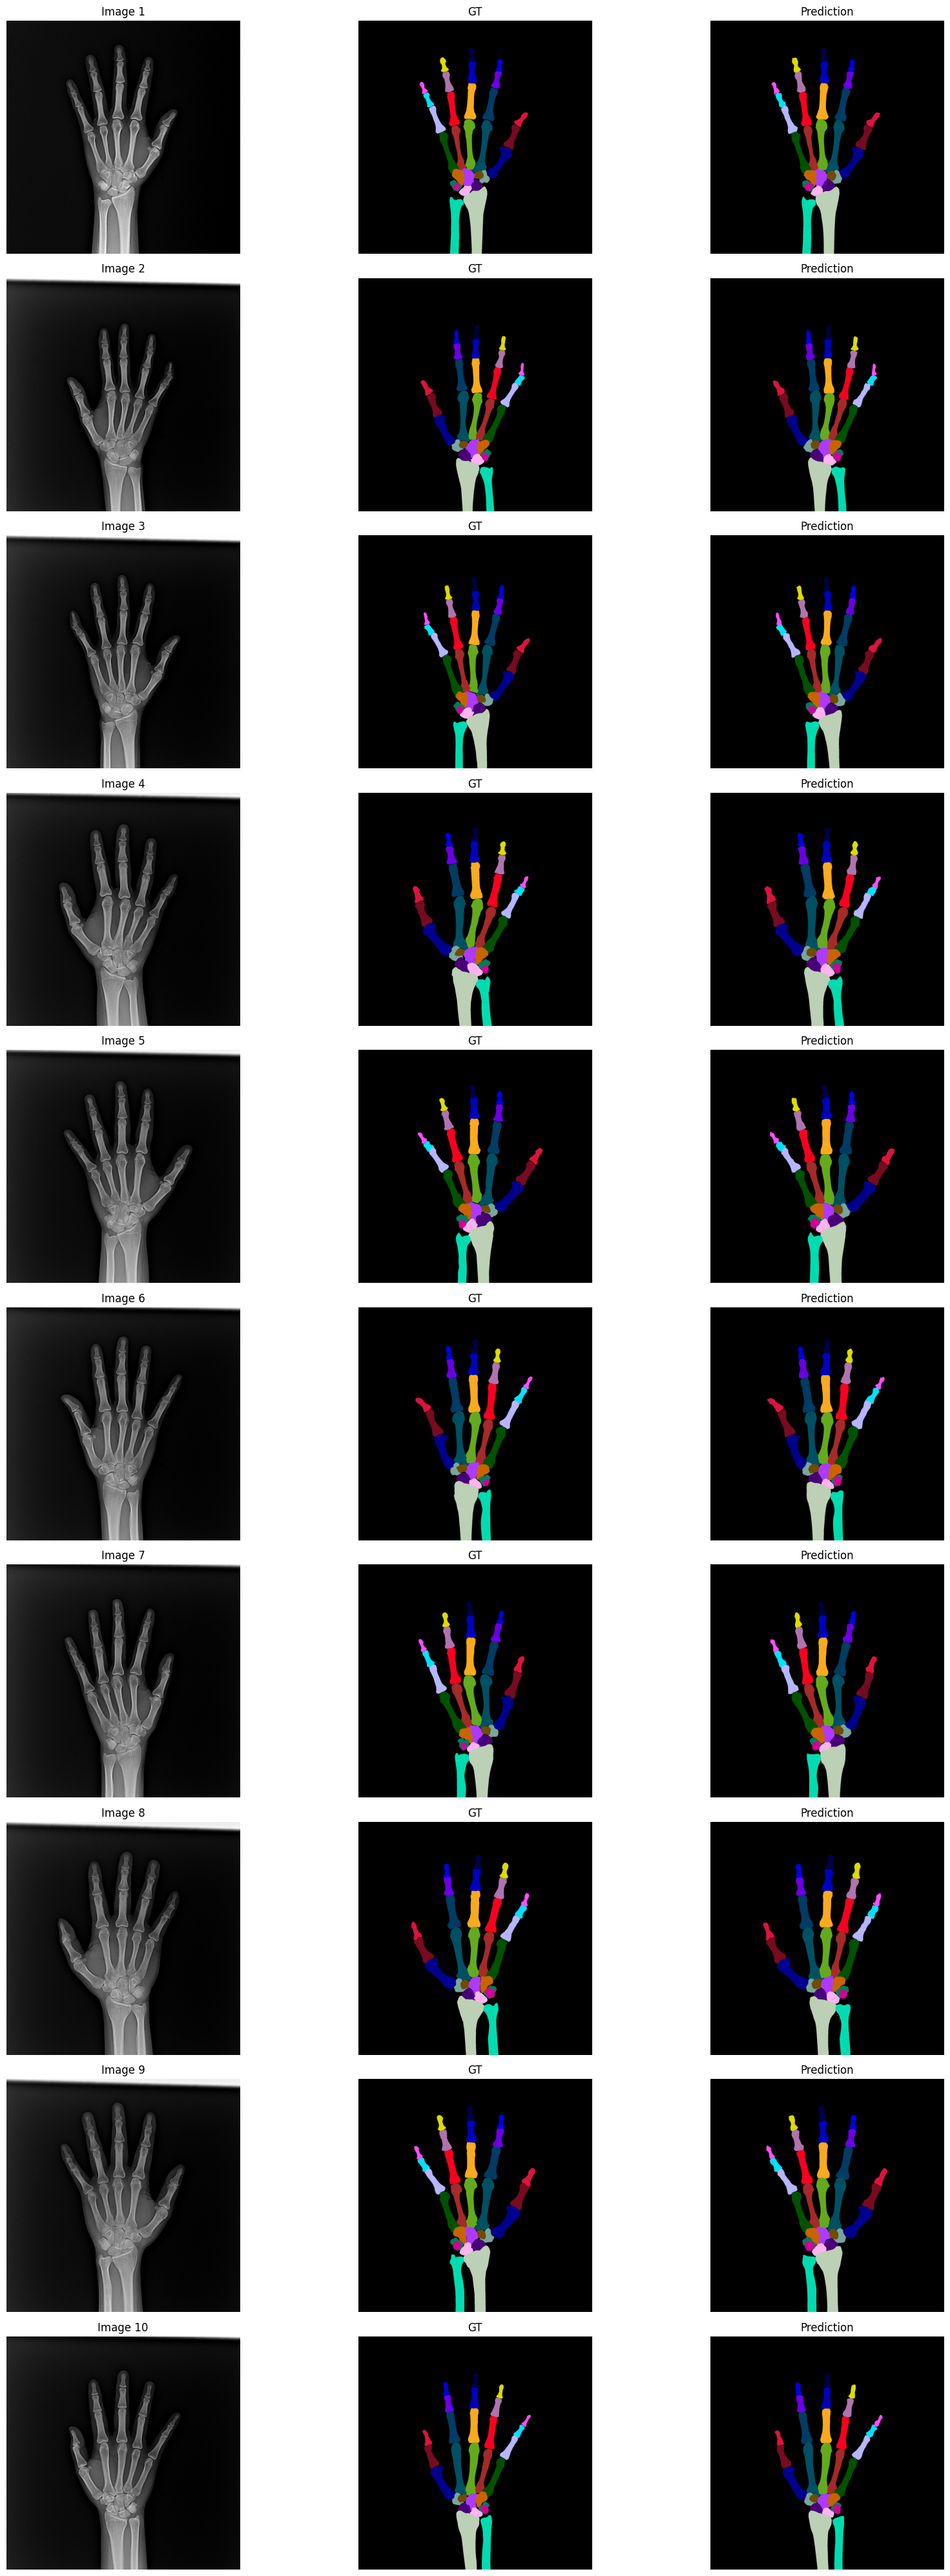

In [19]:
visualization_val_batch(model, valid_dataset, indices=range(1,11), thr=0.5)

In [ ]:
def visualize_difference(model, dataset, indices=range(1, 11), thr=0.5):
    """GT와 Prediction의 차이만 시각화"""
    model.eval()
    n_images = len(indices)
    
    plt.figure(figsize=(8, n_images * 4))
    
    for i, idx in enumerate(indices):
        img, gt = dataset[idx]
        img_input = img.unsqueeze(0).cuda()
        
        with torch.no_grad():
            outputs = model(img_input)['out']
            outputs = F.interpolate(outputs, size=(2048, 2048), mode="bilinear")
            outputs = torch.sigmoid(outputs)
            outputs = (outputs > thr).detach().cpu().numpy()
        
        pred = outputs.squeeze(0)
        gt_np = gt.numpy()
        
        # Difference map 계산
        diff_map = np.zeros((*pred.shape[1:], 3), dtype=np.uint8)
        
        for c in range(pred.shape[0]):
            tp = (gt_np[c] == 1) & (pred[c] == 1)
            fp = (gt_np[c] == 0) & (pred[c] == 1)
            fn = (gt_np[c] == 1) & (pred[c] == 0)
            
            diff_map[tp] = [0, 255, 0]  # Green: True Positive
            diff_map[fp] = [255, 0, 0]  # Red: False Positive
            diff_map[fn] = [0, 0, 255]  # Blue: False Negative
        
        plt.subplot(n_images, 1, i + 1)
        plt.title(f"Image {idx} - Difference (Green=TP, Red=FP, Blue=FN)")
        plt.imshow(img.permute(1, 2, 0).numpy())
        plt.imshow(diff_map, alpha=0.6)
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()


In [21]:
train_dataset.name2idx['image1664154750085.png']

213

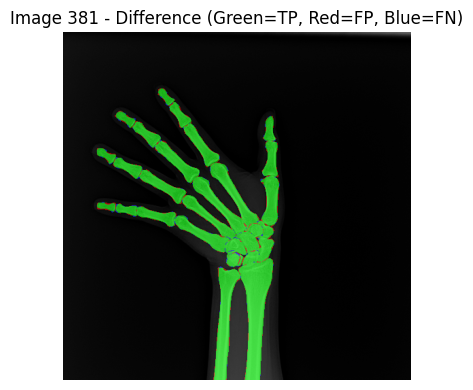

In [28]:
visualize_difference(model, train_dataset, indices=[381], thr=0.5)

In [23]:
visualize_difference(model, valid_dataset, indices=[0, 5, 10], thr=0.5)

ValueError: operands could not be broadcast together with shapes (2048,2048) (512,512) 

<Figure size 800x1200 with 0 Axes>

In [24]:
from calculate_overall_class_metrics import calculate_overall_class_metrics 

In [ ]:
#GT에서 겹치는 픽셀 , 잘못 판단 맞게 판단 클래스별로

In [25]:
import torch
metrics = calculate_overall_class_metrics(
    model, 
    valid_dataset, 
    thr=0.5, 
    class_names=CLASSES
)

Processing 160 images...
  Processed 50/160 images...
  Processed 100/160 images...
  Processed 150/160 images...
Completed processing 160 images!


In [33]:

metrics_df = pd.DataFrame.from_dict(metrics, orient='index')
metrics_df.to_csv('segmentation_metrics.csv', index=True, index_label='Class')

In [ ]:
#test 시각화는 다음에 하자 진짜 개빡치니까


In [ ]:
test_pngs = {
    os.path.relpath(os.path.join(root, fname), start=TEST_IMAGE_ROOT)
    for root, _dirs, files in os.walk(TEST_IMAGE_ROOT)
    for fname in files
    if os.path.splitext(fname)[1].lower() == ".png"
}
test_pngs=sorted(pngs) #정렬할 필요가 있을까? 하면 접근하기 좋지

In [ ]:
#rle 가져와야되니까
test_output=pd.read_csv("../src/datasets/deeplabv3_resnet50_output.csv")

rle_outputs = {}
for _, row in test_output.iterrows():
    image_name = row["image_name"]
    class_name = row["class"]
    rle = row["rle"]
    
    if image_name not in rle_outputs:
        rle_outputs[image_name] = {}
    
    rle_outputs[image_name][class_name] = rle

In [ ]:
# RLE로 인코딩된 결과를 mask map으로 복원합니다.

def decode_rle_to_mask(rle, height, width):
    s = rle.split()
    starts, lengths = [np.asarray(x, dtype=int) for x in (s[0:][::2], s[1:][::2])]
    starts -= 1
    ends = starts + lengths
    img = np.zeros(height * width, dtype=np.uint8)
    
    for lo, hi in zip(starts, ends):
        img[lo:hi] = 1
    
    return img.reshape(height, width)